# 資料增強 — 單階段 9 類分類
每個 Cell 對應一個獨立步驟，可分開執行：
- **Cell 1**：環境設定（只需執行一次）
- **Cell 2**：實驗設定（換參數只改這裡，改完重跑 Cell 4+）
- **Cell 3**：載入資料（只需執行一次，換設定不需重跑）
- **Cell 4**：準備資料集
- **Cell 5**：類別不平衡參數
- **Cell 6**：模型與優化器
- **Cell 7**：訓練
- **Cell 8**：測試集評估
- **Cell 9**：最終圖表
- **Cell 10**：儲存結果（選用）

In [1]:
import sys
sys.path.insert(0, '..')
# Cell 1 — 環境設定（只需執行一次）
%matplotlib inline
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate

from engine.trainer import print_metrics, print_per_class_f1, run_one_epoch, train_model
from engine.visualize import plot_cm, plot_history
from models.builder import build_model
from data.dataset import LABEL_MAP, WaferDataset, augment_minority_classes, extract_labeled_patterned_data, load_raw_data, make_dataloaders, split_df, undersample_none
from utils import make_output_dir, save_results, EpochTimer

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"使用裝置：{device}")

/Users/fe-edward/personal/wafer-map-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


使用裝置：mps


In [2]:
# Cell 2 — 實驗設定（換參數只改這裡，改完重跑 Cell 4+）
EXPERIMENT_NAME    = "augmentation"
IMAGE_SIZE         = (64,64)
BATCH_SIZE         = 32
EPOCHS             = 24
LR                 = 1e-3
RANDOM_SEED        = 42

NONE_CAP = 10000

In [3]:
# Cell 3 — 載入資料（只需執行一次，換設定不用重跑）
print("下載/讀取 WM-811K 資料集...")
df = load_raw_data()
df_with_label, _, _ = extract_labeled_patterned_data(df)
print(f"有標籤資料：{len(df_with_label)} 筆")

下載/讀取 WM-811K 資料集...


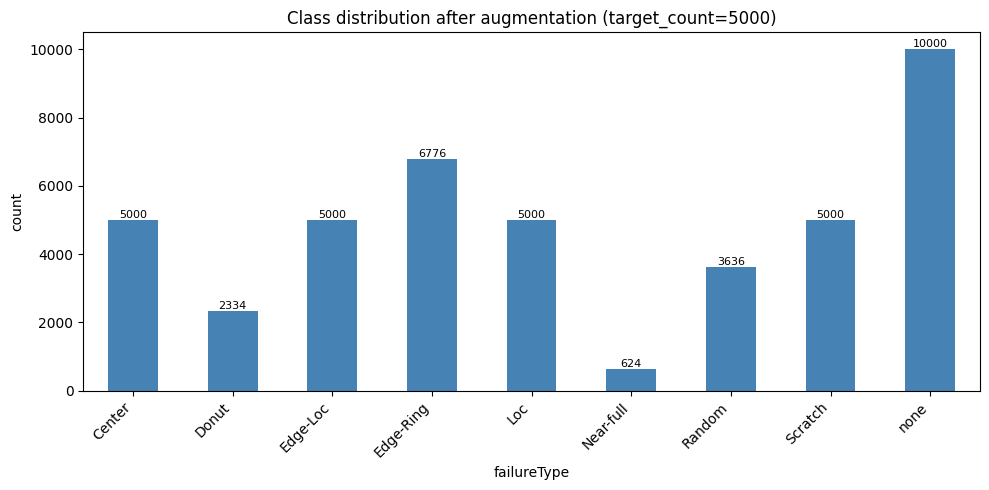

In [4]:
# Cell 4 — 準備資料集
train_df, val_df, test_df = split_df(
    df_with_label, stratify_col="failureType", random_seed=RANDOM_SEED,
)

# 將 None 類別數量降至 10000
train_df = undersample_none(train_df, none_cap=NONE_CAP, random_seed=RANDOM_SEED)

# 對少數缺陷類別做資料增強（翻轉、旋轉），每類補到 target_count
train_df = augment_minority_classes(train_df, target_count=5000, random_seed=RANDOM_SEED)

# 印出資料增強後每種類別（含 none）的數量長條圖
class_counts = train_df["failureType"].value_counts().reindex(LABEL_MAP.keys())
ax = class_counts.plot.bar(color="steelblue", figsize=(10, 5))
ax.set_title("Class distribution after augmentation (target_count=5000)")
ax.set_xlabel("failureType")
ax.set_ylabel("count")
for i, v in enumerate(class_counts):
    ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

num_classes = len(LABEL_MAP)
datasets = {
    "train": WaferDataset(train_df, image_size=IMAGE_SIZE),
    "val":   WaferDataset(val_df, image_size=IMAGE_SIZE),
    "test":  WaferDataset(test_df, image_size=IMAGE_SIZE),
}
dataloaders = make_dataloaders(datasets, BATCH_SIZE)

In [5]:
# Cell 6 — 模型與優化器
model = build_model(num_classes, device)
criterion = nn.CrossEntropyLoss()
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = AdamW(params, lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
print(f"模型與資料集準備完成，類別數：{num_classes}")

模型與資料集準備完成，類別數：9


In [6]:
# Cell 7 — 訓練
timer = EpochTimer()
min_loss_seen = 100
def store_min_loss_seen(val_m, history, epoch):
  timer(val_m, history, epoch)
  global min_loss_seen
  if val_m["loss"] < min_loss_seen:
    min_loss_seen = val_m["loss"]

def loss_guard(val_m, history, epoch):
  return val_m["loss"] <= min_loss_seen * 1.05 # loss 不能超過最小 loss 的 1.05 倍

best_state, best_f1, best_cm, best_f1_per_class, history = train_model(
    model, device, criterion, optimizer, scheduler, dataloaders,
    num_classes=num_classes,
    epochs=EPOCHS,
    lr=LR,
    epoch_callback=store_min_loss_seen,
    checkpoint_guard=loss_guard,
    early_stopping=True, patience=6,
)
print(f"\n訓練完成，最佳驗證 F1：{best_f1:.4f}")

time_per_epoch = timer.get_time_per_epoch()
print(f"Time per epoch: {time_per_epoch:.1f}s")

===== Epoch 1/24 =====
+---------+--------+--------+--------+-------------+----------+
| Split   |   Loss |     F1 |    Acc |   Precision |   Recall |
+=========+========+========+========+=============+==========+
| Train   | 0.8268 | 0.6963 | 0.7113 |      0.7052 |   0.6932 |
+---------+--------+--------+--------+-------------+----------+
| Val     | 0.2735 | 0.7271 | 0.9211 |      0.6558 |   0.8444 |
+---------+--------+--------+--------+-------------+----------+
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|    0.765 |   0.765 |     0.5841 |      0.9269 | 0.5536 |      0.8364 |   0.7442 |    0.4072 | 0.9617 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+

===

In [7]:
# Cell 8 — 測試集評估
model.load_state_dict(best_state)
test_m = run_one_epoch(model, device, dataloaders["test"], criterion, num_classes=num_classes)
print("\n--- Test Results ---")
print(tabulate(
    [[f"{test_m['loss']:.4f}", f"{test_m['f1']:.4f}",
      f"{test_m['acc']:.4f}", f"{test_m['precision']:.4f}", f"{test_m['recall']:.4f}"]],
    headers=["Loss", "F1", "Acc", "Precision", "Recall"],
    tablefmt="grid",
))
print("\n--- Per-Class F1 ---")
print_per_class_f1(test_m["per_class_f1"])


--- Test Results ---
+--------+--------+--------+-------------+----------+
|   Loss |     F1 |    Acc |   Precision |   Recall |
+========+========+========+=============+==========+
| 0.1376 | 0.8369 | 0.9587 |      0.7814 |    0.911 |
+--------+--------+--------+-------------+----------+

--- Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.8849 |  0.8743 |     0.7385 |      0.9715 | 0.6934 |       0.898 |   0.7843 |    0.7067 | 0.9806 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


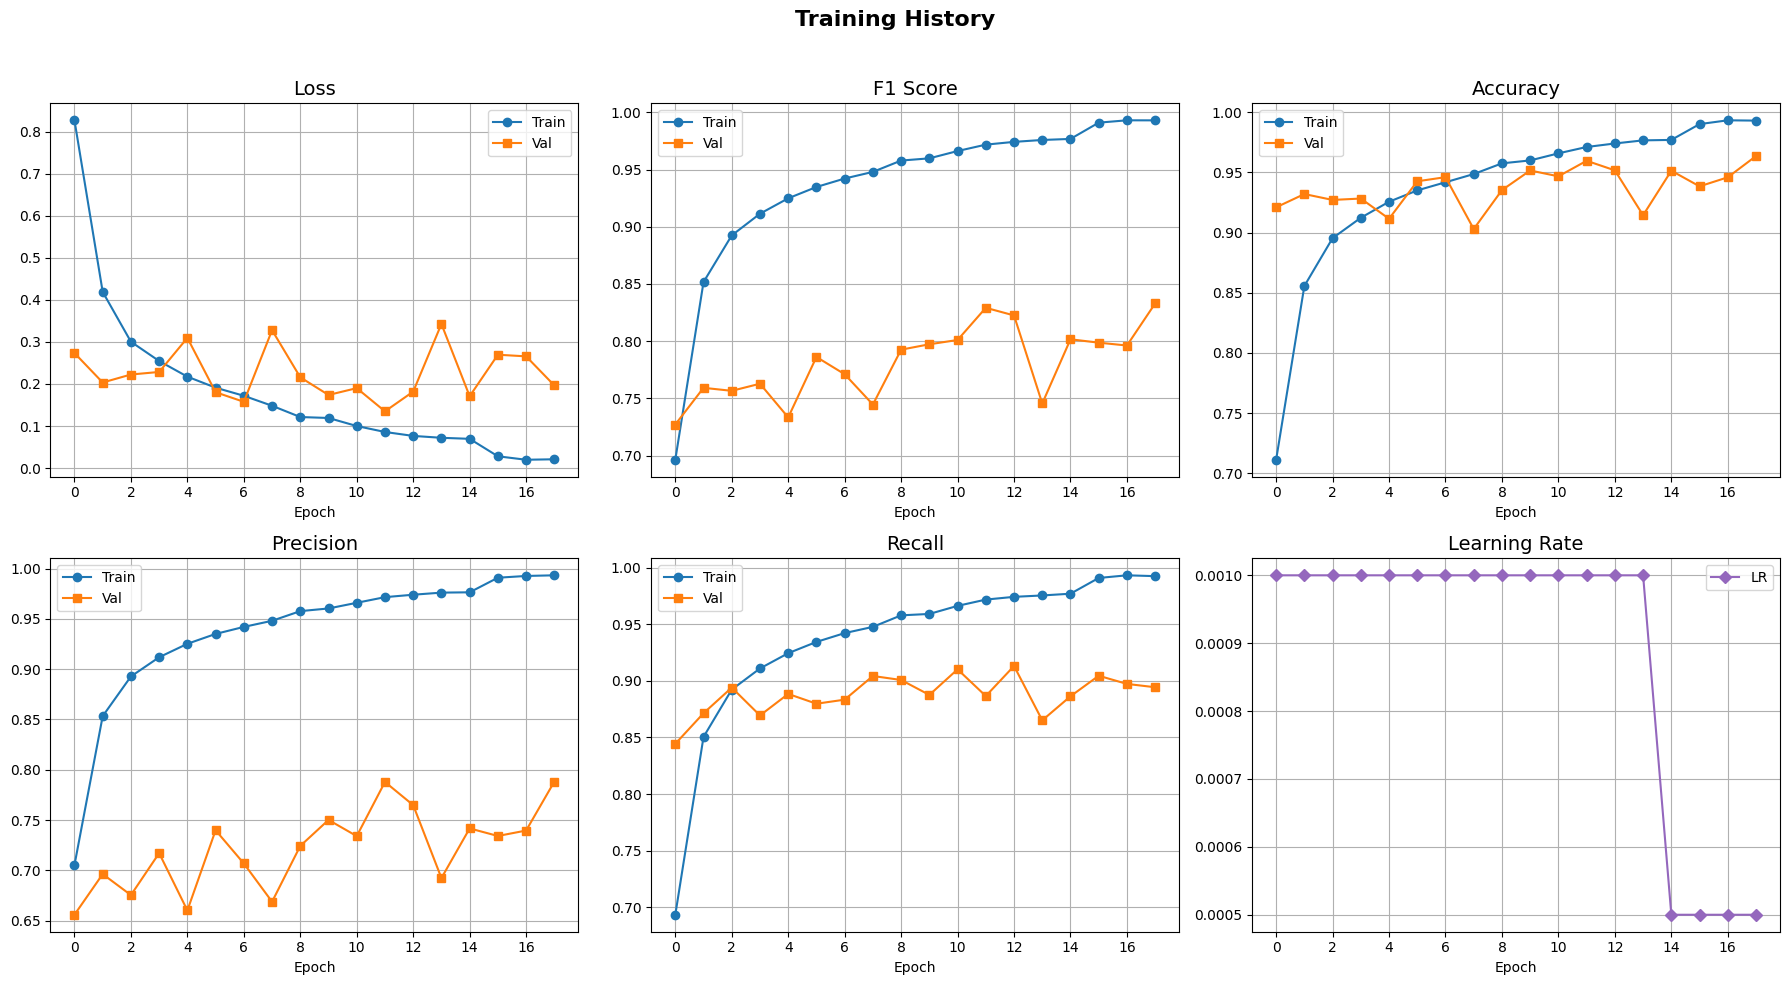

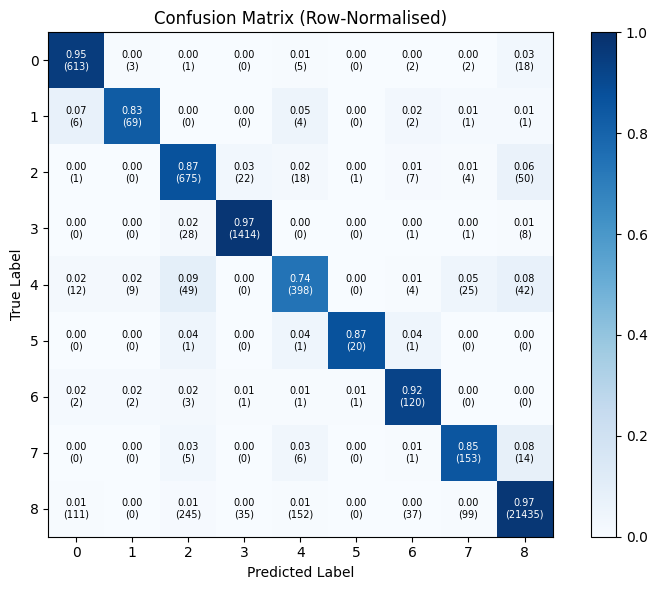


--- Best Val Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.8826 |  0.8313 |     0.7563 |      0.9672 | 0.7082 |      0.8889 |   0.7869 |    0.6595 | 0.9814 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


In [8]:
# Cell 9 — 最終圖表
plot_history(history, show=True)
plot_cm(best_cm, num_classes, show=True)
print("\n--- Best Val Per-Class F1 ---")
print_per_class_f1(best_f1_per_class)

In [ ]:
# Cell 10 — 儲存結果（選用）
out_dir = make_output_dir(EXPERIMENT_NAME, base="../outputs")
save_results(
    out_dir, model, best_state, best_f1, best_cm, best_f1_per_class,
    history, num_classes, LABEL_MAP, IMAGE_SIZE,
)
print(f"結果已儲存至：{out_dir}")

Results saved to ../outputs/augmentation_20260626_141119
結果已儲存至：../outputs/augmentation_20260626_141119


: 

**augementation_20260525_194832** 訓練結果筆記

只做少數量類別的 oversampling，和 none 類別的 undersampling。

IMAGE_SIZE=64，對照組是base